# Workforce Diversity Analysis

This notebook explores US labour force demographics by **sector** and **industry** using BLS-style employment data (2020–2023).

We answer six questions about gender balance, ethnic composition, diversity trends, and clustering — using sector-level data for Q1–Q5 and industry-level data for Q6.

## 1. Load the data

We start by reading the CSV and checking its shape, column types, and missing values.

In [225]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/raw/dataset-google.csv')

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())


(1272, 11)
year                                 float64
sector                                   str
subsector                                str
industry_group                           str
industry                                 str
total_employed_in_thousands          float64
percent_women                        float64
percent_white                        float64
percent_black_or_african_american    float64
percent_asian                        float64
percent_hispanic_or_latino           float64
dtype: object
     year                         sector subsector industry_group industry  \
0  2022.0  Education and health services       NaN            NaN      NaN   
1  2021.0  Education and health services       NaN            NaN      NaN   
2  2023.0                  Manufacturing       NaN            NaN      NaN   
3  2021.0   Transportation and utilities       NaN            NaN      NaN   
4  2021.0       Total, 16 years and over       NaN            NaN      NaN   

   total_em

## 2. Clean the data

A few cleaning steps before analysis:

- Drop rows with missing `year` (blank rows in the CSV)
- Remove the aggregate row `Total, 16 years and over`
- Fix percentage columns stored as whole numbers (e.g. `87.5` → `0.875`)
- Drop rows where `percent_asian > 1.0` (data entry errors)

For Q1–Q5 we use **sector-level rows only** — where `subsector`, `industry_group`, and `industry` are all empty.

In [226]:
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)
df = df[df['sector'] != 'Total, 16 years and over']

pct_cols = [
    'percent_women', 'percent_white', 'percent_black_or_african_american',
    'percent_asian', 'percent_hispanic_or_latino',
]
for col in pct_cols:
    mask = df[col] > 1
    df.loc[mask, col] = df.loc[mask, col] / 100

df = df[df['percent_asian'] <= 1.0]

df_sector = df[
    df['subsector'].isna() & df['industry_group'].isna() & df['industry'].isna()
]

print(f'Cleaned rows: {len(df):,}')
print(f'Sector-level rows: {len(df_sector):,}')
print(f'Years: {sorted(df["year"].unique())}')
print(f'Sectors: {df_sector["sector"].nunique()}')


Cleaned rows: 1,128
Sector-level rows: 52
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Sectors: 13


## 3. Plot styling

Shared colours and seaborn theme used across all charts below. Run this cell once before plotting.

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = {
    'white': '#4C78A8',
    'black': '#54A24B',
    'asian': '#EECA3B',
    'hispanic': '#F58518',
    'women_high': '#72B7B2',
    'women_low': '#E45756',
    'parity': '#9E9E9E',
}

ETHNIC_LABELS = {
    'percent_white': 'White',
    'percent_black_or_african_american': 'Black / African American',
    'percent_asian': 'Asian',
    'percent_hispanic_or_latino': 'Hispanic / Latino',
}

ethnic_cols = [
    'percent_white', 'percent_black_or_african_american',
    'percent_asian', 'percent_hispanic_or_latino',
]

all_demo_cols = ethnic_cols + ['percent_women']

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FFFFFF',
    'axes.edgecolor': '#D0D0D0',
    'axes.labelcolor': '#333333',
    'axes.titleweight': '600',
    'axes.titlesize': 14,
    'grid.alpha': 0.3,
    'legend.frameon': False,
})


def style_ax(ax):
    sns.despine(ax=ax, left=False, bottom=False)
    ax.set_axisbelow(True)
    return ax


---

## Q1 — Which sectors have similar demographic structures?

We group the 13 sectors using **K-Means clustering** on all demographic columns (gender + ethnicity), after standardising the features. We pick **K = 3** using the elbow method and visualise with PCA.

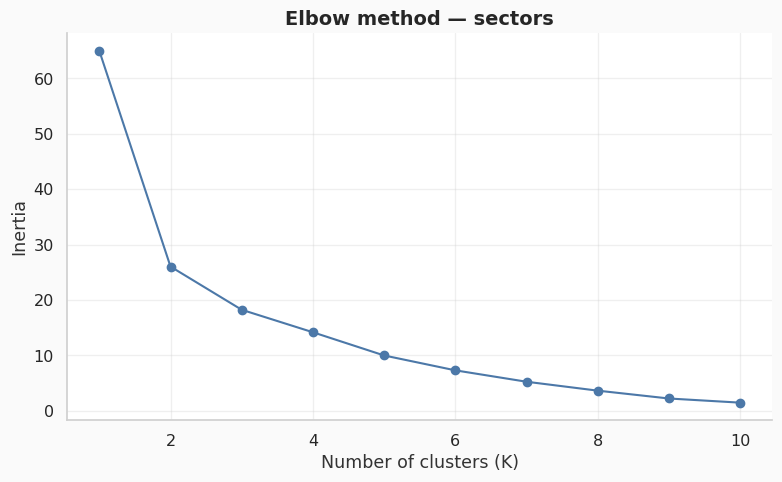

In [228]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df_sec = df_sector.groupby('sector')[all_demo_cols].mean()
scaler = StandardScaler()
X_sec = scaler.fit_transform(df_sec)

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sec)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), inertia, marker='o', color=PALETTE['white'])
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method — sectors')
style_ax(ax)
plt.tight_layout()
plt.show()


In [229]:
km_sec = KMeans(n_clusters=3, random_state=42, n_init=10)
df_sec['cluster'] = km_sec.fit_predict(X_sec)

print(df_sec['cluster'].value_counts().sort_index())
print()
print(df_sec.groupby('cluster')[all_demo_cols].mean().round(3))
print()
print('Cluster 1 sectors:', df_sec[df_sec['cluster'] == 1].index.tolist())
print('Cluster 2 sectors:', df_sec[df_sec['cluster'] == 2].index.tolist())


cluster
0    2
1    8
2    3
Name: count, dtype: int64

         percent_white  percent_black_or_african_american  percent_asian  \
cluster                                                                    
0                0.718                              0.189          0.052   
1                0.771                              0.117          0.078   
2                0.892                              0.051          0.021   

         percent_hispanic_or_latino  percent_women  
cluster                                             
0                             0.167          0.353  
1                             0.172          0.481  
2                             0.256          0.183  

Cluster 1 sectors: ['Education and health services', 'Financial activities', 'Information', 'Leisure and hospitality', 'Manufacturing', 'Other services', 'Professional and business services', 'Wholesale and retail trade']
Cluster 2 sectors: ['Agriculture, forestry, fishing, and hunting', 'Constru

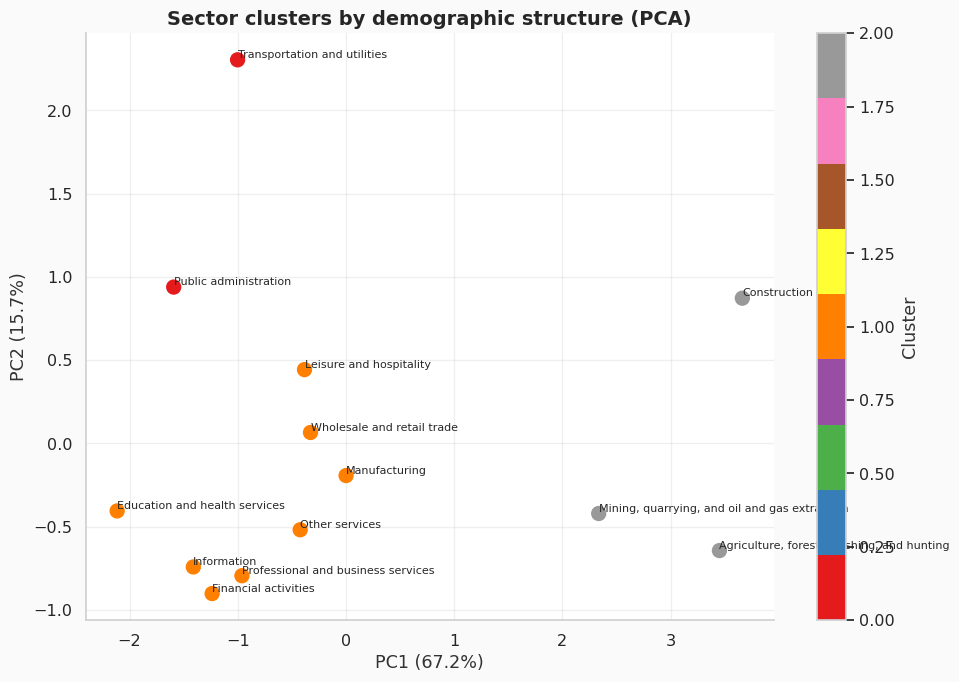

In [230]:
pca_sec = PCA(n_components=2)
X_sec_pca = pca_sec.fit_transform(X_sec)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_sec_pca[:, 0], X_sec_pca[:, 1],
    c=df_sec['cluster'], cmap='Set1', s=100,
)
for i, sector in enumerate(df_sec.index):
    ax.annotate(sector, (X_sec_pca[i, 0], X_sec_pca[i, 1]), fontsize=8, ha='left', va='bottom')

plt.colorbar(scatter, label='Cluster', ax=ax)
ax.set_xlabel(f'PC1 ({pca_sec.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_sec.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Sector clusters by demographic structure (PCA)')
style_ax(ax)
plt.tight_layout()
plt.show()


### Q1 — Findings

Using K-Means (K=3) on 13 sectors across all demographic columns. PCA explains ~83% of variance across 2 components.

| Cluster | Label | Sectors | Key characteristics |
|---------|-------|---------|---------------------|
| 0 | Diverse and gender balanced | 10 sectors | ~46% women, spread across ethnicities |
| 1 | Male + white dominant | Agriculture, Mining | 22% women, 90% white, 22% Hispanic |
| 2 | Most male + Hispanic | Construction | 11% women, 88% white, 32% Hispanic |

**Key insights:**

1. **Most sectors cluster together** — 10 of 13 share broadly similar demographic profiles.
2. **Agriculture and Mining are natural partners** — both male-dominated, overwhelmingly white, with significant Hispanic representation.
3. **Construction stands alone** — the most extreme on gender (89% male) and Hispanic concentration (32%).

---

## Q2 — Which sectors are most gender imbalanced?

We rank sectors by how far `percent_women` sits from 50/50 parity. A **weighted score** multiplies that gap by each sector's share of total employment, so large sectors count more.

In [231]:
gender_size = df_sector.groupby('sector').agg(
    percent_women=('percent_women', 'mean'),
    total_employed=('total_employed_in_thousands', 'sum'),
).sort_values('percent_women')

gender_size['percent_total_employed'] = (
    gender_size['total_employed'] / gender_size['total_employed'].sum()
)
gender_size['gender_imbalance'] = abs(gender_size['percent_women'] - 0.5)
gender_size['weighted_imbalance'] = (
    gender_size['gender_imbalance'] * gender_size['percent_total_employed']
)

gender_size.sort_values('weighted_imbalance', ascending=False).head(5)


,percent_women,total_employed,percent_total_employed,gender_imbalance,weighted_imbalance
sector,,,,,
Education and health services,0.74575,140585.0,0.226860,0.24575,0.055751
Construction,0.10925,45743.0,0.073815,0.39075,0.028843
Manufacturing,0.29500,60069.0,0.096933,0.20500,0.019871
Transportation and utilities,0.24625,37957.0,0.061251,0.25375,0.015542
Professional and business services,0.42050,79474.0,0.128246,0.07950,0.010196


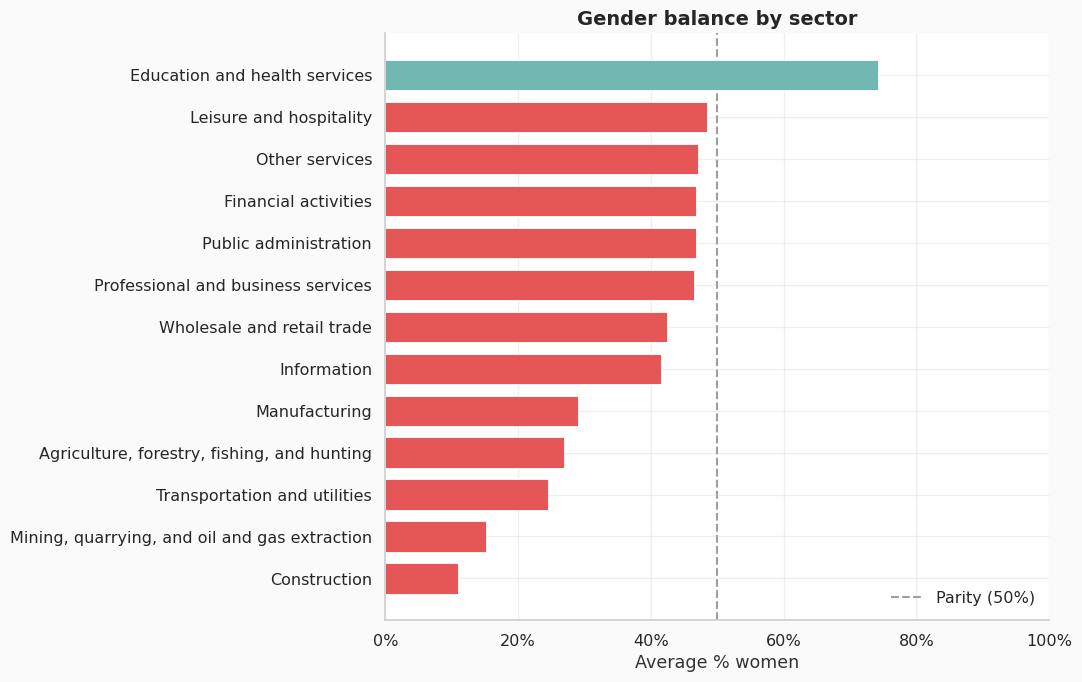

In [232]:
gender_all = df.groupby('sector')['percent_women'].mean().sort_values()
colors = [
    PALETTE['women_low'] if v < 0.5 else PALETTE['women_high']
    for v in gender_all.values
]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(gender_all.index, gender_all.values * 100, color=colors,
        edgecolor='white', linewidth=0.6, height=0.72)
ax.axvline(x=50, color=PALETTE['parity'], linestyle='--', linewidth=1.5,
           label='Parity (50%)', zorder=0)
ax.set_xlim(0, 100)
ax.set_xlabel('Average % women')
ax.set_title('Gender balance by sector')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
style_ax(ax)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Q2 — Findings

Weighted imbalance = |percent_women − 0.5| × workforce share

| Sector | % Women | Direction | Workforce share |
|--------|--------:|-----------|----------------:|
| Education and health services | 74.6% | Female dominated | 23.1% |
| Construction | 11.0% | Male dominated | 5.6% |
| Manufacturing | 29.5% | Male dominated | 9.9% |

Construction is the most imbalanced in raw terms (89% male) but ranks 2nd on the weighted score because it employs only 5.6% of workers. Education & health ranks highest because its imbalance affects the largest workforce.

---

## Q3 — Which sectors shifted most between 2021 and 2023?

We compare each sector's demographic percentages in 2021 vs 2023 and sum the absolute changes across all five demographic columns to get a **total shift** score.

In [233]:
df_2021 = df_sector[df_sector['year'] == 2021].set_index('sector')
df_2023 = df_sector[df_sector['year'] == 2023].set_index('sector')

shift = df_2023[all_demo_cols] - df_2021[all_demo_cols]
shift['total_shift'] = shift[all_demo_cols].abs().sum(axis=1)

shift.sort_values('total_shift', ascending=False).head(10).multiply(100).round(2)


,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,percent_women,total_shift
sector,,,,,,
"Mining, quarrying, and oil and gas extraction",0.8,0.4,-0.8,5.4,-0.1,7.5
Financial activities,-1.9,0.7,1.2,0.2,-1.0,5.0
Professional and business services,-1.7,1.1,0.2,1.0,-0.4,4.4
Leisure and hospitality,-1.3,0.6,0.5,1.7,-0.1,4.2
Other services,-0.4,0.4,0.1,1.8,1.4,4.1
Information,-0.8,-0.6,1.0,0.4,-1.0,3.8
Transportation and utilities,-1.1,1.1,0.1,1.0,-0.5,3.8
Public administration,-1.1,1.5,0.2,0.2,-0.3,3.3
Manufacturing,-1.1,0.5,0.5,0.7,0.3,3.1


### Q3 — Findings

| Sector | Total shift | Key driver |
|--------|------------:|------------|
| Mining | 7.5% | Hispanic/Latino +5.4% |
| Financial activities | 5.0% | White −1.9%, Asian +1.2%, Black +0.7% |
| Professional and business services | 4.4% | White −1.7%, Black +1.1% |

All three show `percent_white` declining while minority representation grows. Mining's shift is driven almost entirely by Hispanic/Latino growth.

---

## Q4 — Which sectors are dominated by a single ethnic group?

For each sector we average ethnic percentages across years and find the **dominant group** (highest share). Note: Hispanic/Latino is an ethnicity that overlaps with racial categories, so the four columns do not sum to 100%.

In [234]:
ethnic = df_sector.groupby('sector')[ethnic_cols].mean()
ethnic['dominant_group'] = ethnic[ethnic_cols].idxmax(axis=1)
ethnic['dominant_pct'] = ethnic[ethnic_cols].max(axis=1)
ethnic['diversity_score'] = ethnic[ethnic_cols].apply(
    lambda x: -sum((p * np.log(p)) for p in x if p > 0), axis=1
)
ethnic['total_employed'] = df_sector.groupby('sector')['total_employed_in_thousands'].mean()

ethnic.sort_values('dominant_pct', ascending=False)


,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,dominant_group,dominant_pct,diversity_score,total_employed
sector,,,,,,,,
"Agriculture, forestry, fishing, and hunting",0.92050,0.03175,0.01025,0.24850,percent_white,0.92050,0.578725,2298.50
Construction,0.87925,0.06425,0.01975,0.32700,percent_white,0.87925,0.732542,11435.75
"Mining, quarrying, and oil and gas extraction",0.87575,0.05650,0.03350,0.19350,percent_white,0.87575,0.710136,619.50
Manufacturing,0.79150,0.10475,0.07275,0.17475,percent_white,0.79150,0.916899,15017.25
Other services,0.78500,0.10350,0.07700,0.20825,percent_white,0.78500,0.948955,7265.75
Wholesale and retail trade,0.77975,0.12175,0.06075,0.18950,percent_white,0.77975,0.935735,19465.25
Financial activities,0.77900,0.11400,0.08050,0.12775,percent_white,0.77900,0.907796,10855.50
Professional and business services,0.76925,0.10225,0.09875,0.16775,percent_white,0.76925,0.963072,19868.50
Information,0.75725,0.11425,0.09800,0.12725,percent_white,0.75725,0.948384,2788.25


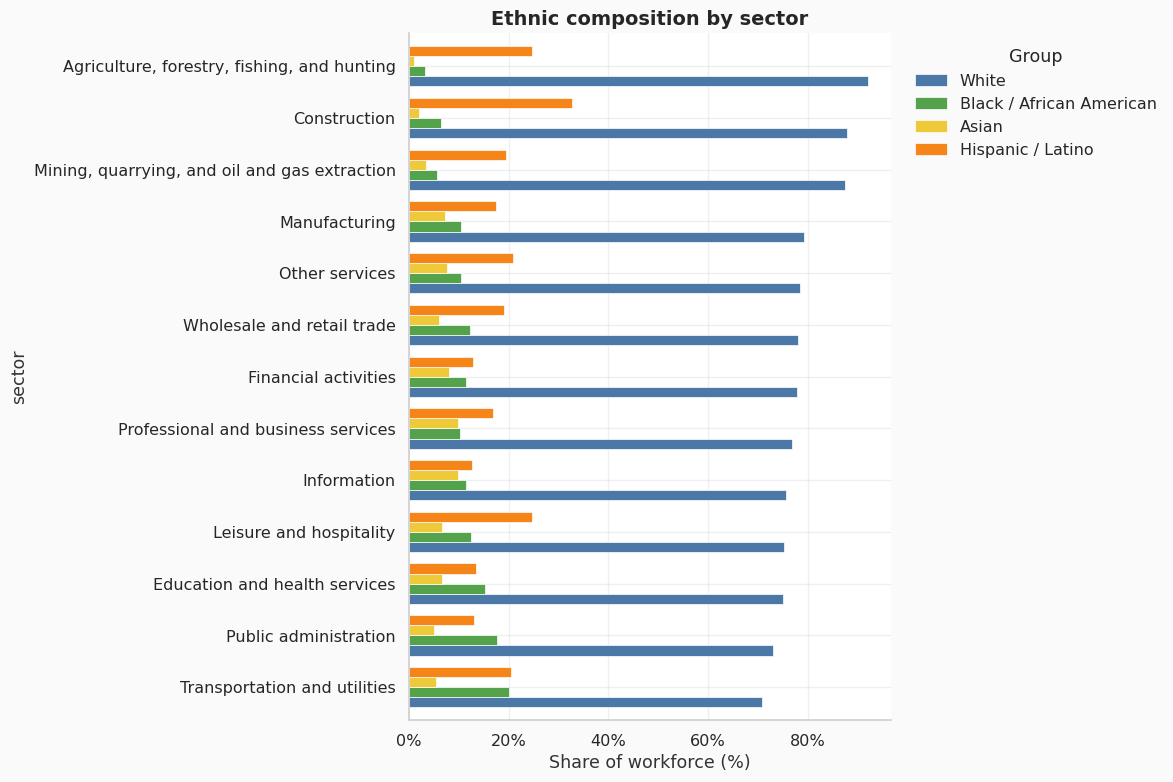

In [235]:
plot_df = (
    ethnic[ethnic_cols].multiply(100).round(1)
    .sort_values('percent_white', ascending=True)
    .rename(columns=ETHNIC_LABELS)
)
ethnic_colors = [PALETTE['white'], PALETTE['black'], PALETTE['asian'], PALETTE['hispanic']]

fig, ax = plt.subplots(figsize=(12, 8))
plot_df.plot(kind='barh', ax=ax, color=ethnic_colors, width=0.78,
             edgecolor='white', linewidth=0.5)
ax.set_xlabel('Share of workforce (%)')
ax.set_title('Ethnic composition by sector')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
style_ax(ax)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Group')
plt.tight_layout()
plt.show()


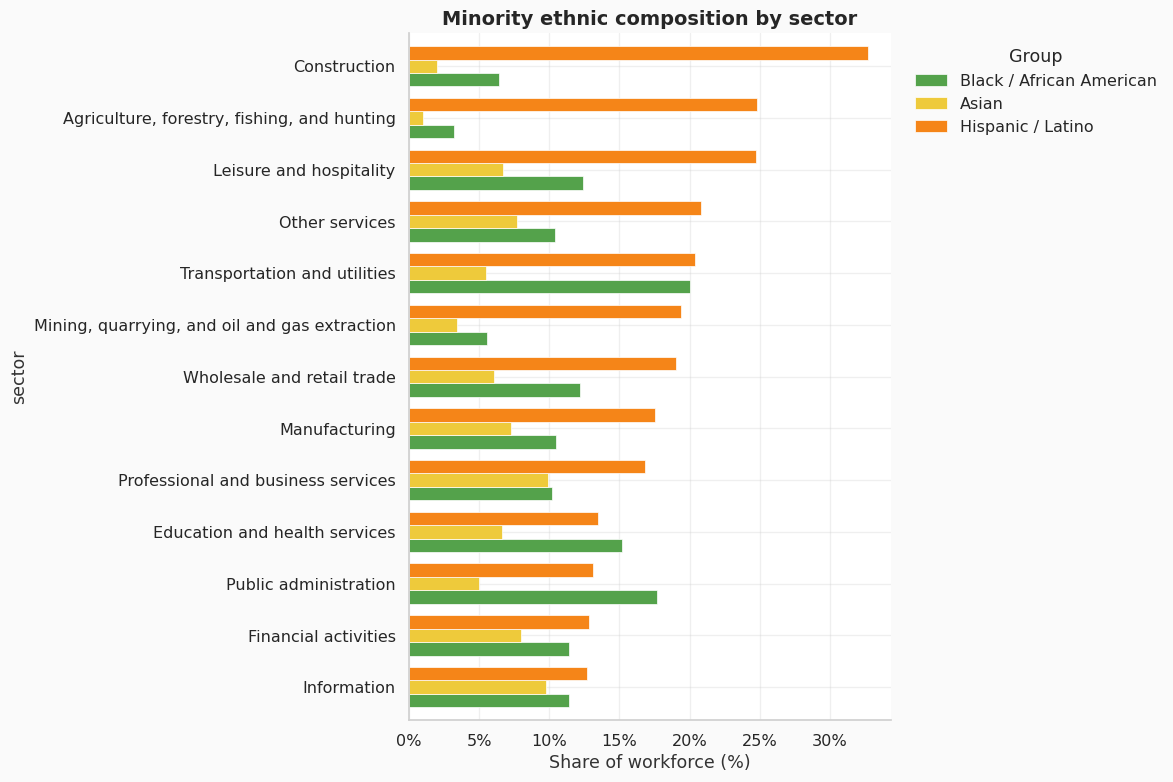

In [236]:
minority_cols = ethnic_cols[1:]
minority_colors = [PALETTE['black'], PALETTE['asian'], PALETTE['hispanic']]

plot_df = (
    ethnic[minority_cols].multiply(100).round(1)
    .sort_values('percent_hispanic_or_latino', ascending=True)
    .rename(columns=ETHNIC_LABELS)
)

fig, ax = plt.subplots(figsize=(12, 8))
plot_df.plot(kind='barh', ax=ax, color=minority_colors, width=0.78,
             edgecolor='white', linewidth=0.5)
ax.set_xlabel('Share of workforce (%)')
ax.set_title('Minority ethnic composition by sector')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
style_ax(ax)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Group')
plt.tight_layout()
plt.show()


### Q4 — Findings

**Dominant group across all sectors: White workers**

| Sector | White % | Most notable minority |
|--------|--------:|-----------------------|
| Agriculture | 92.1% | Hispanic/Latino 24.9% |
| Construction | 88.1% | Hispanic/Latino 32.3% |
| Mining | 87.6% | Hispanic/Latino 19.4% |
| Manufacturing | 79.2% | Hispanic/Latino 17.5% |
| Transportation & utilities | 70.8% | Black/AA 20.0% |

1. **White dominance is universal** — ranging from 71% to 92%; no sector is ethnically balanced.
2. **Agriculture and Construction are most extreme** — 88–92% white with Hispanic as the main secondary group.
3. **Transportation is the most relatively diverse** — lowest white share at 70.8%.

---

## Q5 — Which sectors are most ethnically diverse, and how does that relate to size?

We use a **Shannon entropy score** on the four ethnic columns — higher means more spread across groups. We then compare diversity to average sector employment (thousands).

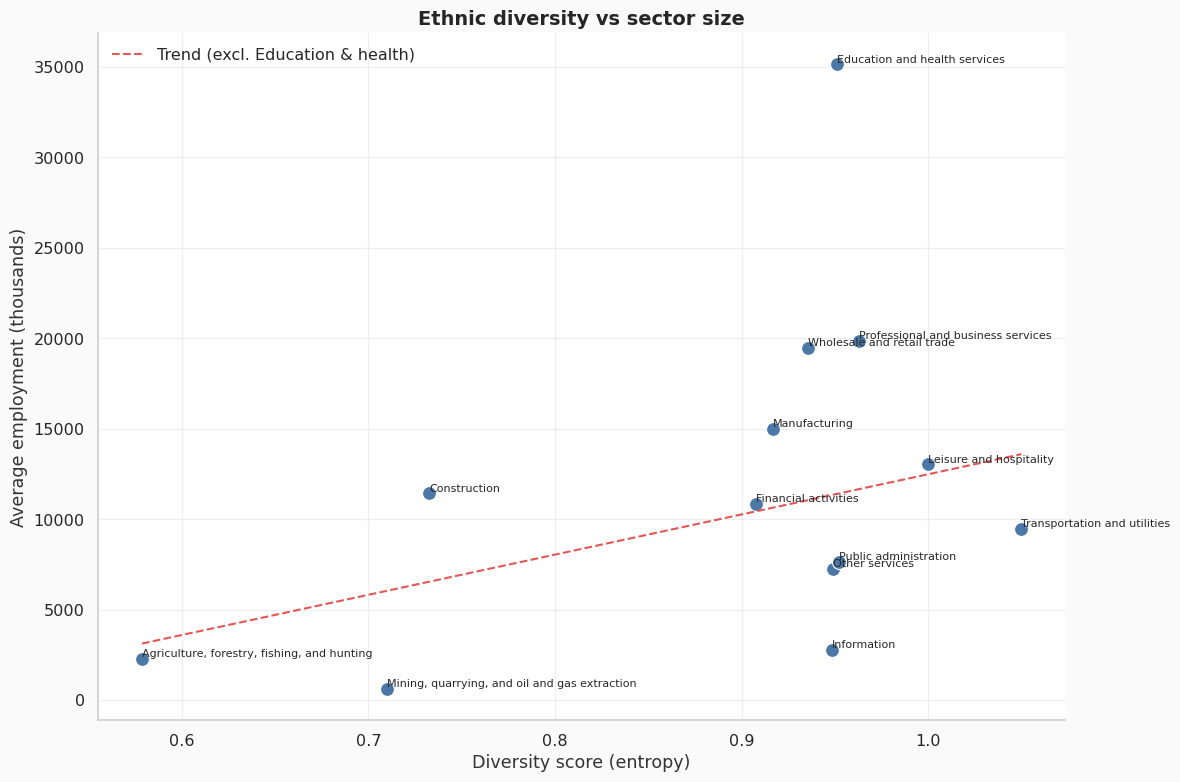

In [237]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=ethnic.reset_index(), x='diversity_score', y='total_employed',
    s=100, color=PALETTE['white'], edgecolor='white', linewidth=0.8, ax=ax,
)
for _, row in ethnic.reset_index().iterrows():
    ax.annotate(row['sector'], (row['diversity_score'], row['total_employed']),
                fontsize=8, ha='left', va='bottom')

ethnic_no_edu = ethnic[ethnic.index != 'Education and health services']
m, b = np.polyfit(ethnic_no_edu['diversity_score'], ethnic_no_edu['total_employed'], 1)
x_line = np.linspace(ethnic['diversity_score'].min(), ethnic['diversity_score'].max(), 100)
ax.plot(x_line, m * x_line + b, color=PALETTE['women_low'], linestyle='--',
        linewidth=1.5, label='Trend (excl. Education & health)')

ax.set_xlabel('Diversity score (entropy)')
ax.set_ylabel('Average employment (thousands)')
ax.set_title('Ethnic diversity vs sector size')
style_ax(ax)
ax.legend()
plt.tight_layout()
plt.show()


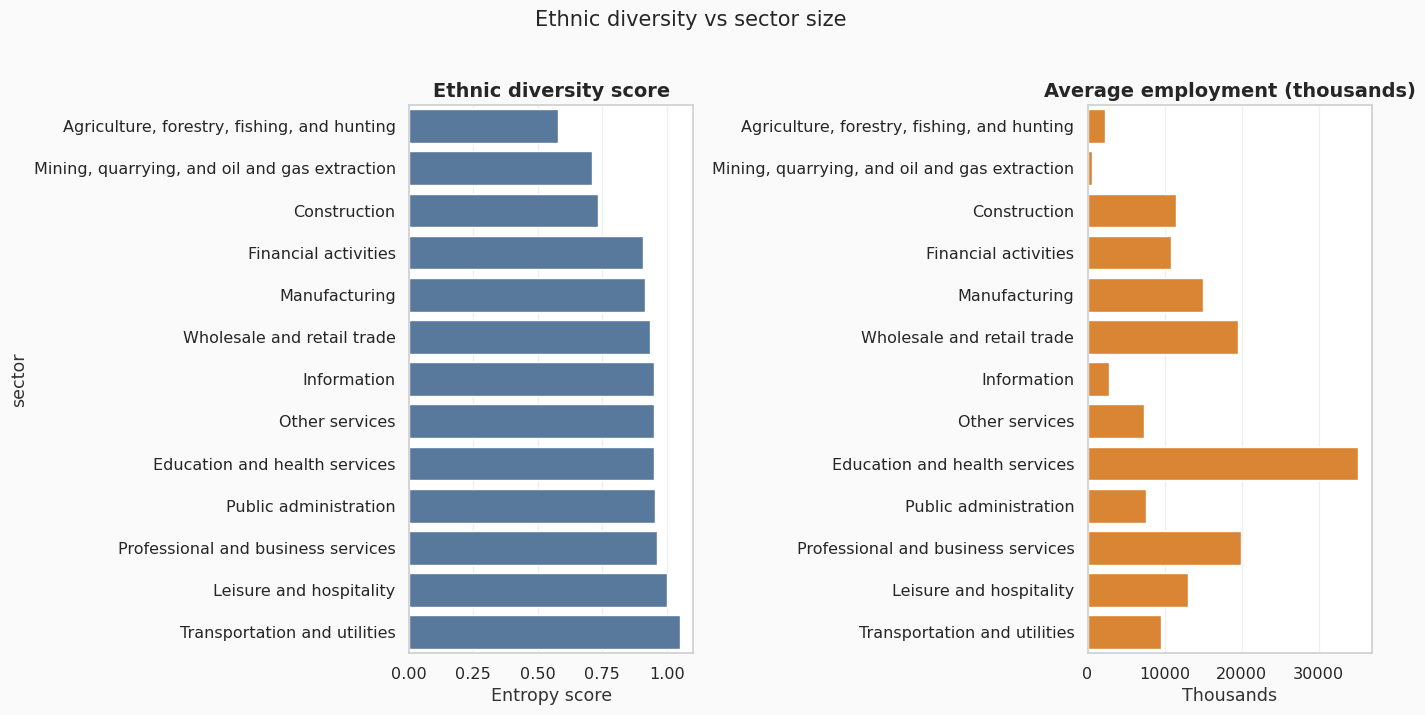

In [238]:
ethnic_sorted = ethnic.sort_values('diversity_score', ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.barplot(x='diversity_score', y='sector', data=ethnic_sorted.reset_index(),
            color=PALETTE['white'], ax=axes[0])
axes[0].set_title('Ethnic diversity score')
axes[0].set_xlabel('Entropy score')

sns.barplot(x='total_employed', y='sector', data=ethnic_sorted.reset_index(),
            color=PALETTE['hispanic'], ax=axes[1])
axes[1].set_title('Average employment (thousands)')
axes[1].set_xlabel('Thousands')
axes[1].set_ylabel('')

plt.suptitle('Ethnic diversity vs sector size', y=1.02)
plt.tight_layout()
plt.show()


### Q5 — Findings

| Rank | Sector | Diversity score | Avg employment | Workforce share |
|------|--------|----------------:|---------------:|----------------:|
| 1 | Transportation & utilities | 1.05 | 9,489k | 6.1% |
| 2 | Leisure & hospitality | 1.00 | 13,033k | 8.4% |
| 3 | Professional & business services | 0.96 | 19,869k | 12.8% |
| 4 | Public administration | 0.95 | 7,642k | 4.9% |
| 5 | Education & health services | 0.95 | 35,146k | 22.7% |

**Least diverse:** Agriculture (0.58), Mining (0.71), Construction (0.73).

There is a **modest positive association** between diversity and size (r ≈ 0.42). Larger sectors tend to sit in the mid-to-high diversity range, but the fit is loose — Construction is large yet among the least diverse; Transportation is the most diverse but only mid-sized.

---

## Q6 — Which industries share similar ethnic compositions?

Unlike Q1–Q5, this question uses **industry-level rows** (~110 unique industries). We cluster them on ethnic composition only, using K-Means with K=4 (from the elbow method).

Industries: 110


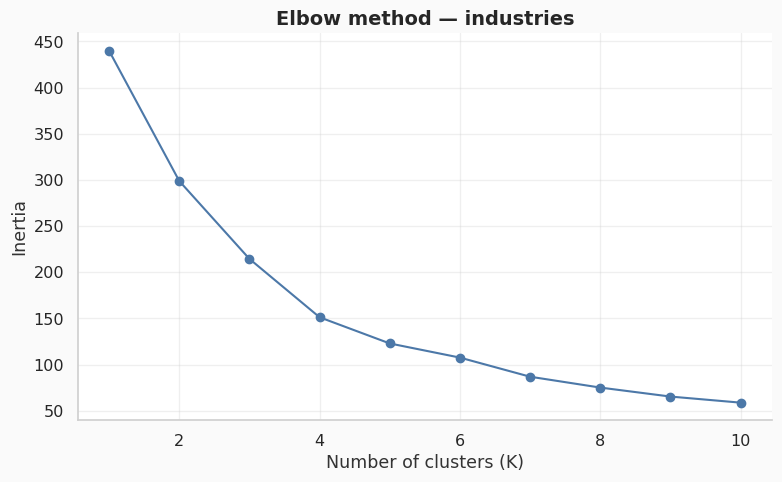

In [239]:
df_industry = df[df['industry'].notna()]
df_ind = df_industry.groupby('industry')[ethnic_cols].mean().dropna()
print(f'Industries: {len(df_ind)}')

X = scaler.fit_transform(df_ind)

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 11), inertia, marker='o', color=PALETTE['white'])
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow method — industries')
style_ax(ax)
plt.tight_layout()
plt.show()


In [240]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ind['cluster'] = km.fit_predict(X)

print(df_ind['cluster'].value_counts().sort_index())
print()
print(df_ind.groupby('cluster')[ethnic_cols].mean().round(3))
print()
print('Asian outlier cluster (cluster 3):')
print(df_ind[df_ind['cluster'] == 3].index.tolist())


cluster
0    14
1     5
2    70
3    21
Name: count, dtype: int64

         percent_white  percent_black_or_african_american  percent_asian  \
cluster                                                                    
0                0.739                              0.149          0.070   
1                0.630                              0.075          0.264   
2                0.833                              0.087          0.048   
3                0.698                              0.217          0.048   

         percent_hispanic_or_latino  
cluster                              
0                             0.348  
1                             0.117  
2                             0.166  
3                             0.144  

Asian outlier cluster (cluster 3):
['Automotive equipment rental and leasing', 'Business support services', 'Child day care services', 'Civic, social, advocacy organizations, and grantmaking and giving services', 'Community food and housing, and e

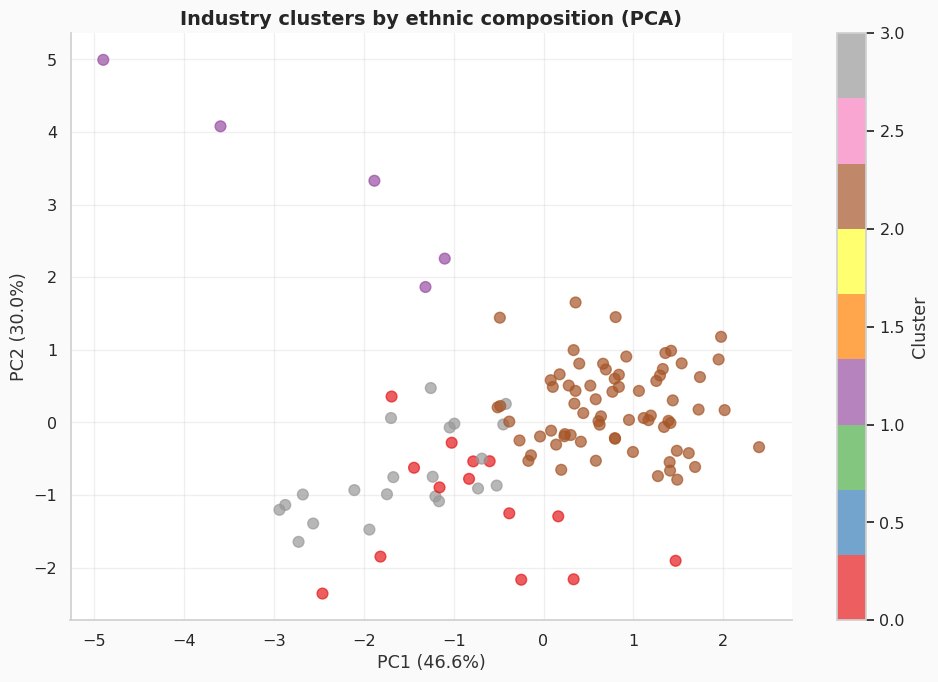

In [241]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_ind['cluster'],
                     cmap='Set1', s=60, alpha=0.7)
plt.colorbar(scatter, label='Cluster', ax=ax)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Industry clusters by ethnic composition (PCA)')
style_ax(ax)
plt.tight_layout()
plt.show()


### Q6 — Findings

K-Means (K=4) on 110 industries. PCA explains ~77% of variance.

| Cluster | Label | Industries | Defining characteristic |
|---------|-------|----------:|------------------------|
| 1 | White dominant | 71 | 83% white, low minority across all groups |
| 0 | White-Black mix | 22 | 70% white, highest Black at 21% |
| 2 | White-Hispanic mix | 14 | 74% white, highest Hispanic at 35% |
| 3 | Asian concentrated | 3 | 57% white, 32% Asian — clear outliers |

Most industries (71/110) cluster as predominantly white. The meaningful variation is *which* minority group is largest. Three industries (Computer manufacturing, Electronic components, Nail salons) form a distinct Asian-concentrated outlier cluster.

---

## Summary

**Data:** 13 sectors, ~110 industries, 2020–2023. Sector-level for Q1–Q5, industry-level for Q6.

1. **Most sectors cluster together demographically** — Construction, Agriculture, and Mining are the outliers.
2. **Gender imbalance hits hardest in Education & health** — largest sector + most female-dominated.
3. **Diversity is slowly improving** — Mining, Financial, and Professional services shifted most 2021–2023.
4. **White dominance is universal** — "diversity" here means relative spread, not balance.
5. **Asian concentration is the most distinctive industry outlier** — 3 industries at 25–40% Asian.
6. **Sector size and diversity are weakly positively related** — but exceptions like Construction are common.